<a href="https://colab.research.google.com/github/aryancodes12/Advance-Machine-Learning/blob/main/Loan_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
filepath = "/content/drive/MyDrive/CDPL SEM 3/dataset/Loan prediction.csv"

In [14]:
import pandas as pd

In [15]:
data = pd.read_csv(filepath)

In [16]:
df = pd.DataFrame(data)

#EDA

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [18]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [19]:
data.shape

(614, 13)

In [20]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [21]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [22]:
data.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


#Values Count Check

In [23]:
data["Gender"].value_counts()

,count
Gender,
Male,489
Female,112


In [24]:
data["Married"].value_counts()

,count
Married,
Yes,398
No,213


In [25]:
data["Dependents"].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [26]:
data["Education"].value_counts()

,count
Education,
Graduate,480
Not Graduate,134


In [27]:
data["Self_Employed"].value_counts()

,count
Self_Employed,
No,500
Yes,82


In [28]:
data["Property_Area"].value_counts()

,count
Property_Area,
Semiurban,233
Urban,202
Rural,179


In [29]:
data["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


In [30]:
data['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


In [31]:
data['Credit_History'].value_counts()

,count
Credit_History,
1.0,475
0.0,89


#Unique Values Check

In [32]:
data['Gender'].unique()

array(['Male', 'Female', nan], dtype=object)

In [33]:
data['Married'].unique()

array(['No', 'Yes', nan], dtype=object)

In [34]:
data['Education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [35]:
data['Self_Employed'].unique()

array(['No', 'Yes', nan], dtype=object)

In [36]:
data['Loan_Amount_Term'].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [37]:
data['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [38]:
data['Credit_History'].unique()

array([ 1.,  0., nan])

In [39]:
data['Property_Area'].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [40]:
data['Loan_Status'].unique()

array(['Y', 'N'], dtype=object)

#Replacing Categorial column with Mode

In [41]:
cat_cols = ['Gender','Married','Dependents',
            'Self_Employed','Credit_History']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [42]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [43]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [44]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,614.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.855049
std,6109.041673,2926.248369,85.587325,65.12041,0.352339
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


#Univariate Data Analysis

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

#Histogram For Numerical Values

#Visualization of Numerical Columns

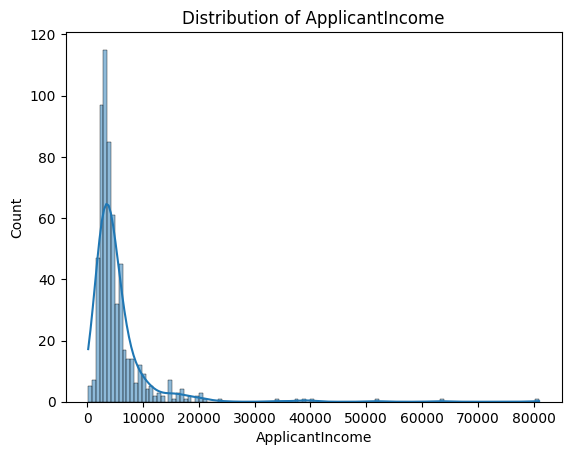

<Figure size 400x400 with 0 Axes>

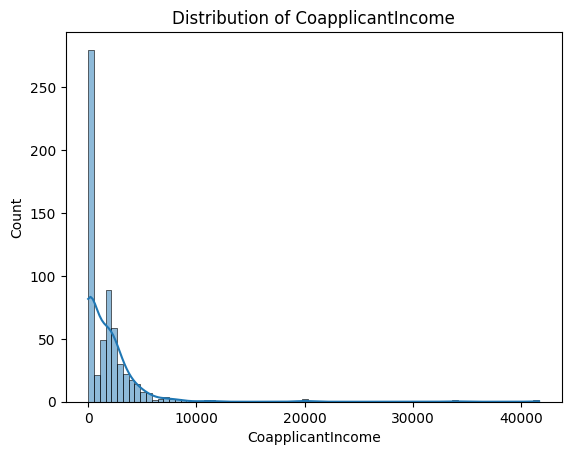

<Figure size 400x400 with 0 Axes>

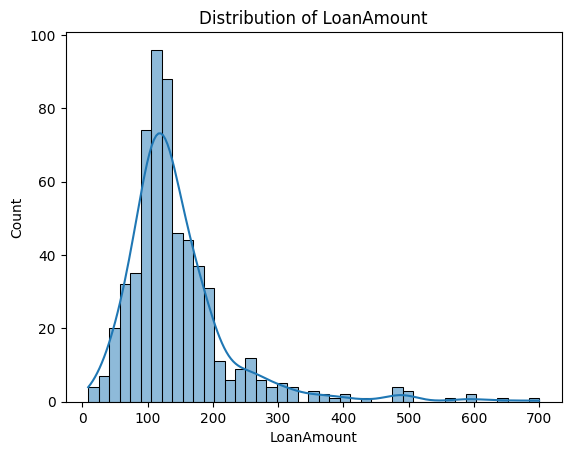

<Figure size 400x400 with 0 Axes>

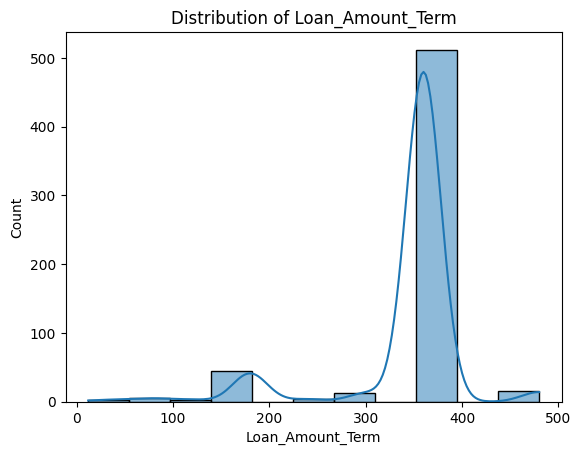

<Figure size 400x400 with 0 Axes>

In [46]:
numerical_cols = ['ApplicantIncome',
            'CoapplicantIncome',
            'LoanAmount',
            'Loan_Amount_Term']

for col in numerical_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.figure(figsize=(4,4))
    plt.show()
    print("\n\n")

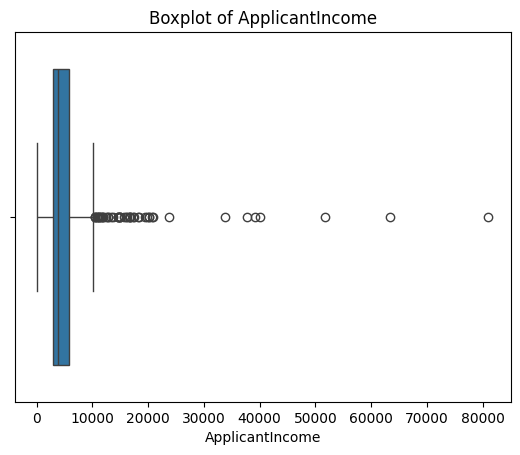

<Figure size 400x400 with 0 Axes>

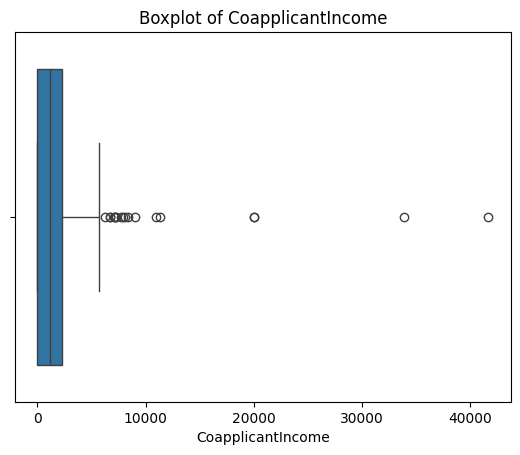

<Figure size 400x400 with 0 Axes>

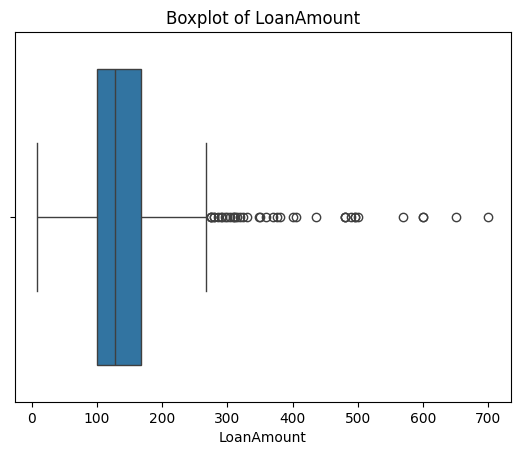

<Figure size 400x400 with 0 Axes>

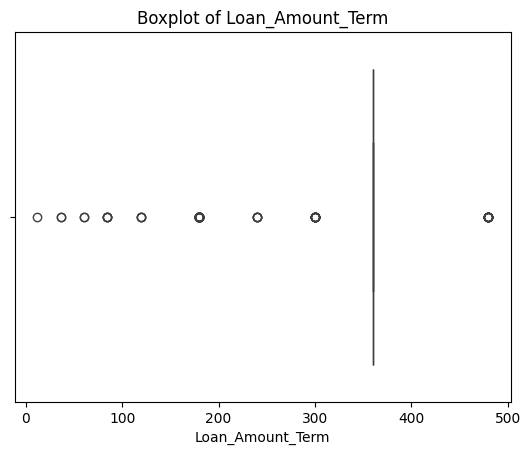

<Figure size 400x400 with 0 Axes>

In [47]:
for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.figure(figsize=(4,4))
    plt.show()

#Visualization on Categorical columns

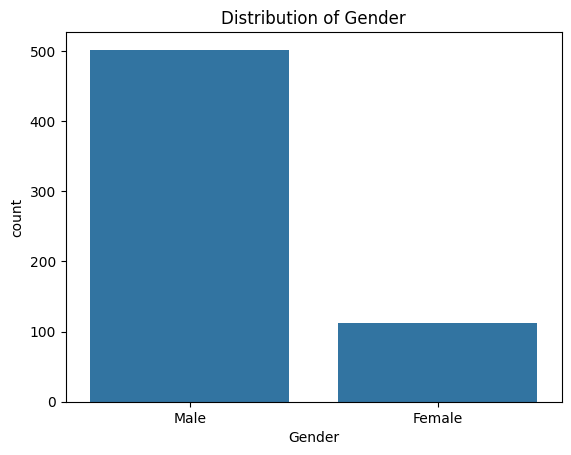

<Figure size 600x400 with 0 Axes>

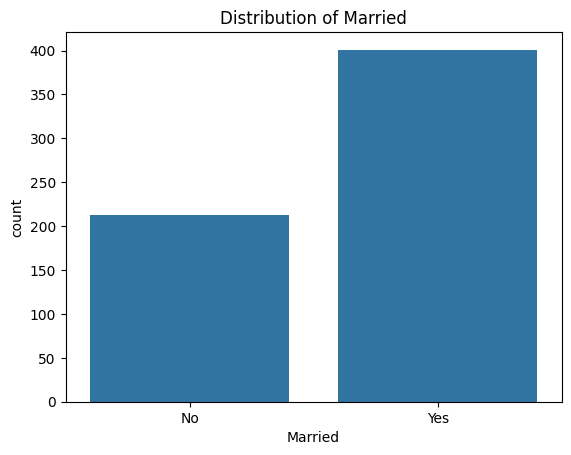

<Figure size 600x400 with 0 Axes>

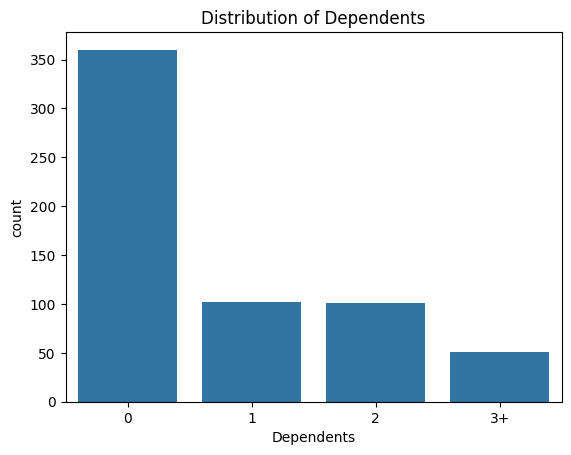

<Figure size 600x400 with 0 Axes>

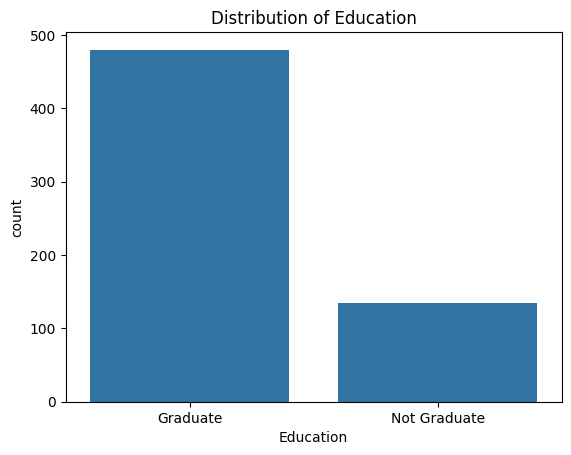

<Figure size 600x400 with 0 Axes>

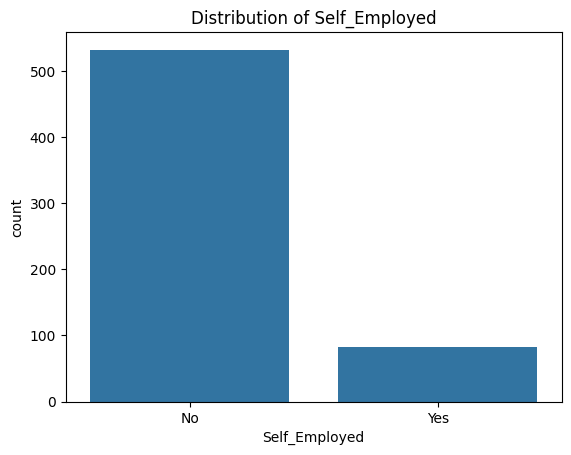

<Figure size 600x400 with 0 Axes>

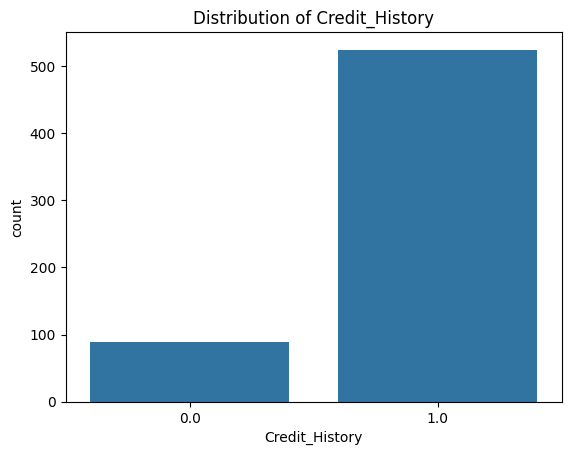

<Figure size 600x400 with 0 Axes>

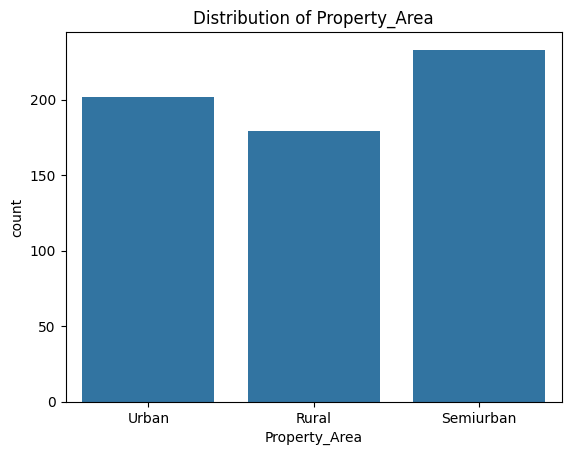

<Figure size 600x400 with 0 Axes>

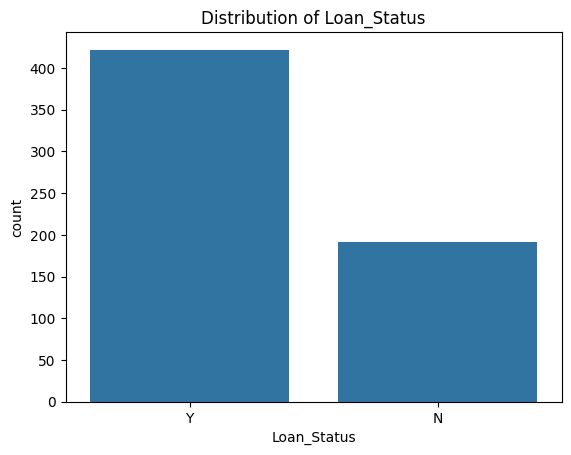

<Figure size 600x400 with 0 Axes>

In [48]:
categorial_cols = ['Gender','Married','Dependents',
            'Education','Self_Employed',
            'Credit_History',
            'Property_Area','Loan_Status']

for col in categorial_cols:
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.figure(figsize=(6,4))
    plt.show()

#Bivariate Analysis

In [49]:
df.corr(numeric_only=True)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.018615
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,0.011134
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.001463
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.000445
Credit_History,-0.018615,0.011134,-0.001463,0.000445,1.000000


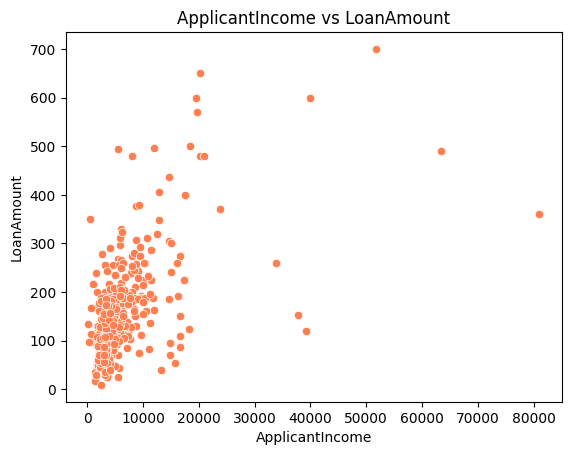

In [50]:
#Scatterplot of ApplicantIncome vs LoanAmount
sns.scatterplot(data = data ,x="ApplicantIncome", y ="LoanAmount", color = "coral")
plt.title("ApplicantIncome vs LoanAmount")
plt.xlabel("ApplicantIncome")
plt.ylabel("LoanAmount")
plt.show()

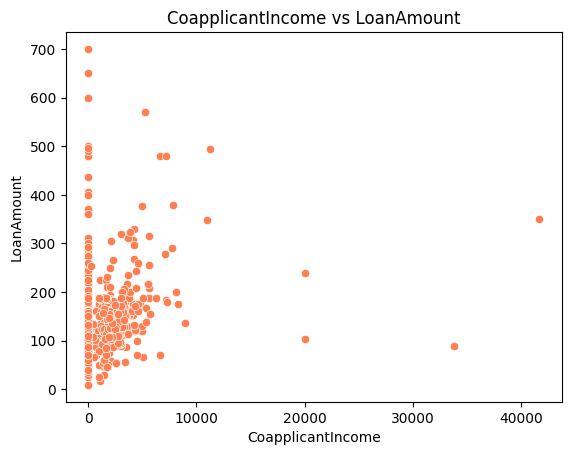

In [51]:
#Scatterplot of CoapplicantIncome vs LoanAmount
sns.scatterplot(data = data ,x="CoapplicantIncome", y ="LoanAmount", color = "coral")
plt.title("CoapplicantIncome vs LoanAmount")
plt.xlabel("CoapplicantIncome")
plt.ylabel("LoanAmount")
plt.show()

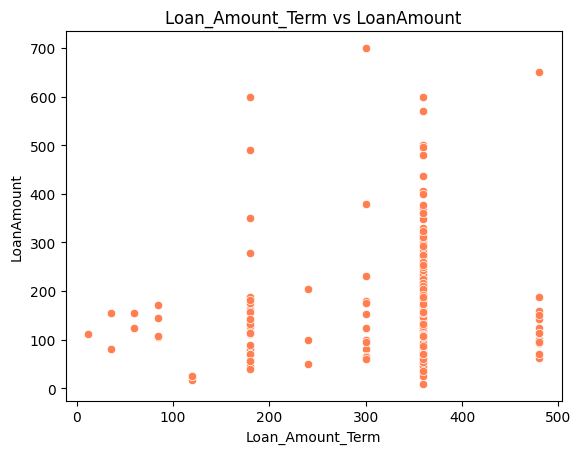

In [52]:
#Scatterplot of Loan_Amount_Term vs LoanAmount
sns.scatterplot(data = data ,x="Loan_Amount_Term", y ="LoanAmount", color = "coral")
plt.title("Loan_Amount_Term vs LoanAmount")
plt.xlabel("Loan_Amount_Term")
plt.ylabel("LoanAmount")
plt.show()

#Multivariate Analysis

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [54]:
# Drop Loan_ID column
df = df.drop('Loan_ID', axis=1)

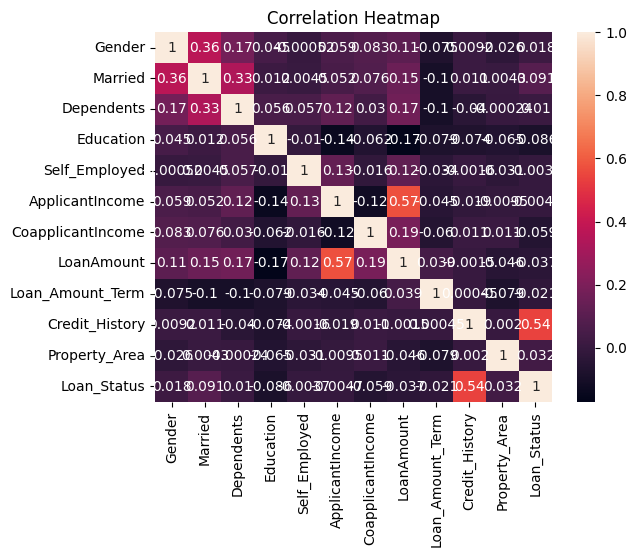

In [55]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Ensure all categorical columns in df are numerically encoded
# The previous LabelEncoder application in cell 0p3TEz2kbmto seems not to have persisted on 'df' or 'df' was overwritten.
# Re-applying LabelEncoder here for robustness.
le = LabelEncoder()
for col in df.select_dtypes(include=np.object_).columns:
    df[col] = le.fit_transform(df[col])

sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [56]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,0


#Violin Chart

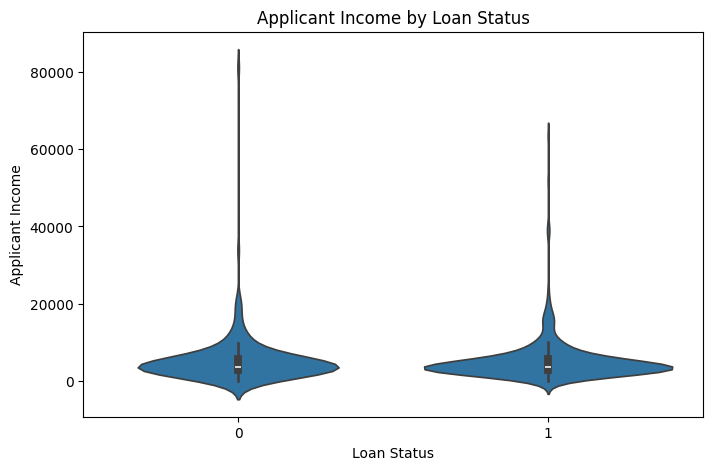

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Loan_Status', y='ApplicantIncome')

plt.title("Applicant Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")
plt.show()

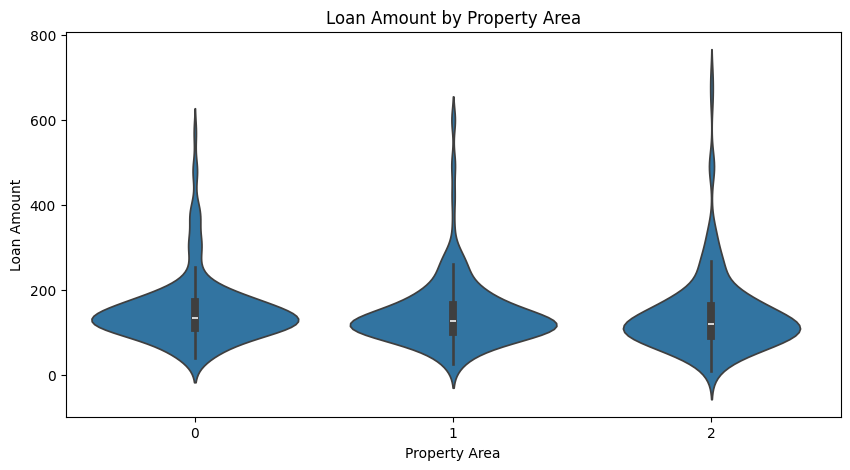

In [58]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df, x='Property_Area', y='LoanAmount')

plt.title("Loan Amount by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Loan Amount")
plt.show()

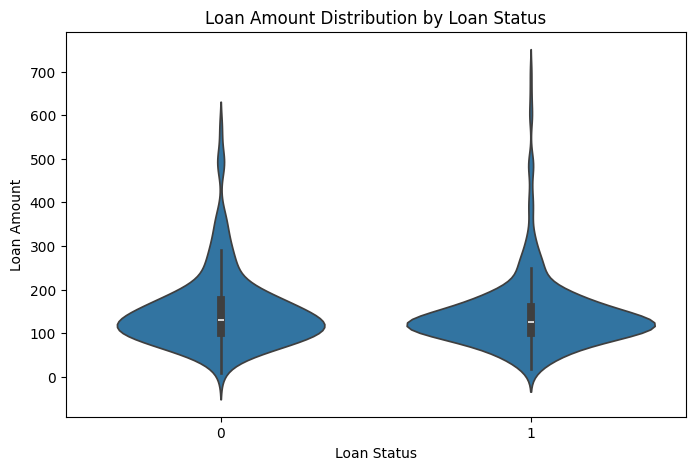

In [59]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Loan_Status', y='LoanAmount')

plt.title("Loan Amount Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

#Spliting the Data

In [60]:
if "Loan_ID" in df.columns:
    df = df.drop("Loan_ID", axis=1)

## Handling missing values

In [61]:
categorical_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numeric_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]



In [62]:
# Fill categorical missing values with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values with median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [65]:
x = df.drop("LoanAmount", axis = 1)
y = df["LoanAmount"]

In [68]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in x.select_dtypes(include="object").columns:

    le = LabelEncoder()

    x[col] = le.fit_transform(X[col])

    encoders[col] = le


target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)


print("\nFeature encoders:")
for col in encoders:
    print(col, ":", encoders[col].classes_)

print("\nTarget classes:")
print(target_encoder.classes_)


Feature encoders:

Target classes:
[  9.  17.  25.  26.  30.  35.  36.  40.  42.  44.  45.  46.  47.  48.
  50.  53.  54.  55.  56.  58.  59.  60.  61.  62.  63.  65.  66.  67.
  70.  71.  72.  73.  74.  75.  76.  78.  80.  81.  83.  84.  85.  86.
  87.  88.  89.  90.  93.  94.  95.  96.  97.  98.  99. 100. 101. 102.
 103. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113. 114. 115. 116.
 117. 118. 119. 120. 121. 122. 123. 124. 125. 126. 127. 128. 129. 130.
 131. 132. 133. 134. 135. 136. 137. 138. 139. 140. 141. 142. 143. 144.
 145. 146. 148. 149. 150. 151. 152. 153. 154. 155. 156. 157. 158. 159.
 160. 161. 162. 164. 165. 166. 167. 168. 170. 172. 173. 175. 176. 178.
 180. 181. 182. 184. 185. 186. 187. 188. 190. 191. 192. 194. 196. 200.
 201. 205. 207. 208. 209. 210. 211. 214. 216. 218. 225. 228. 230. 234.
 236. 239. 240. 242. 243. 244. 246. 250. 253. 255. 258. 259. 260. 265.
 267. 275. 279. 280. 286. 290. 292. 296. 300. 304. 308. 311. 312. 315.
 320. 324. 330. 349. 350. 360. 370. 376. 

In [69]:
x.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,360.0,1.0,2,1


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB


In [73]:
df.describe()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.817590,0.653094,0.744300,0.218241,0.133550,5403.459283,1621.245798,145.752443,342.410423,0.855049,1.037459,0.687296
std,0.386497,0.476373,1.009623,0.413389,0.340446,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.787482,0.463973
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,2.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,2.000000,1.000000


#Model Selection

In [79]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
)

In [80]:

#statstical model
# 1. Linear model

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

#predicting y
y_pred_lr = lr.predict(x_test)

#r2 score
from sklearn.metrics import r2_score
r2_score_lr = r2_score(y_test, y_pred_lr)

#print r2 score in int
print(r2_score_lr)

0.2658737778255228


In [81]:
#2 .Decision Tree model

from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)

#predicting y
y_pred_dt = dt.predict(x_test)

#r2 score
r2_score_dt = r2_score(y_test,y_pred_dt)

#print r2 score
print(r2_score_dt)

0.014430086466998393


In [82]:
#3. Random forest model

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train,y_train)


#predicting y
y_pred_rf = rf.predict(x_test)

#r2 score
r2_score_rf = r2_score(y_test,y_pred_rf)

#print r2 score
print(r2_score_rf)


0.3726926308315506


In [83]:
#4. Xgboost model

from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(x_train,y_train)

#predict y
y_predict_xgb = xgb.predict(x_test)

#r2 score
r2_score_xgb = r2_score(y_test,y_predict_xgb)

#print r2 score
print(r2_score_xgb)

0.2638587951660156


In [84]:
#Distance Based model
#1.KNN
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(x_train,y_train)

#predicting y
y_pred_knn = knn.predict(x_test)

#r2 score
r2_score_knn = r2_score(y_test,y_pred_knn)

#print r2 score
print(r2_score_knn)

0.3104951592215651


In [85]:
#MAE and MSE, RMSE

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

mae_rf = mean_absolute_error(y_test,y_pred_rf)
mse_rf = mean_squared_error(y_test,y_pred_rf)
rmse_rf = root_mean_squared_error(y_test,y_pred_rf)

print(mae_rf)
print(mse_rf)
print(rmse_rf)

25.777084010840106
1152.0143037904245
33.94133621103366


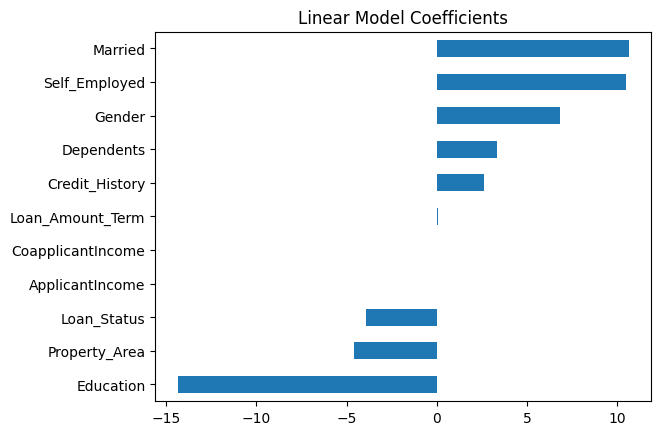

In [87]:
#feature importance to lr model

coefficients = pd.Series(lr.coef_, index=x.columns)
coefficients.sort_values().plot(kind='barh', title='Linear Model Coefficients')
plt.show()

#Downloading the Model

In [ ]:
#Downloading the lr model
import joblib
joblib.dump(lr,"Loan_Prediction_model.pkl")

In [ ]:
# downloading model in system
from google.colab import files
files.download("Loan_Prediction_model.pkl")

In [ ]:
#downloding label encoder
joblib.dump(le, "label_encoder_loan.pkl")
files.download("label_encoder_loan.pkl")